In [44]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

from tensorflow.keras import layers
from tensorflow.keras import models

In [45]:
df = pd.read_csv('waterQuality1.csv')

In [46]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   str    
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uranium      7999

In [48]:
df.isnull().sum()

aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64

In [49]:
df.replace('#NUM!', np.nan, inplace=True)
df.dropna(inplace=True)

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 7996 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   str    
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium      7996 non-

In [51]:
x = df.drop("is_safe",axis=1)
y = df['is_safe']

In [52]:
labelencoder = LabelEncoder()
scaler = StandardScaler()

columnasOriginales = x.columns
x = scaler.fit_transform(x)
x

array([[ 0.77740287, -0.58549134, -0.48087476, ...,  1.05369443,
         1.33873624, -0.91704015],
       [ 1.30694501,  0.77511802, -0.59963176, ...,  1.05369443,
         0.85113427,  0.19802266],
       [ 0.27157158, -0.02908321, -0.48087476, ...,  0.70612871,
         2.03531047, -1.28872776],
       ...,
       [-0.45556091, -0.83666343, -0.63921743, ..., -1.72683135,
        -0.75098648,  0.19802266],
       [-0.51878982, -0.48186877, -0.59963176, ..., -1.72683135,
        -1.02961617, -1.66041536],
       [-0.49507898, -0.83666343, -0.59963176, ..., -1.72683135,
        -0.75098648,  0.19802266]], shape=(7996, 20))

In [53]:
y = labelencoder.fit_transform(y)
y

array([1, 1, 0, ..., 1, 1, 1], shape=(7996,))

In [54]:
df[columnasOriginales] = x
df['is_safe'] = y.astype(str)

In [55]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,0.777403,-0.585491,-0.480875,1.054205,-0.993241,-0.711941,2.152993,-0.973050,-1.657446,-0.363345,...,-0.781070,1.129767,-0.348629,0.609178,1.203362,1.661842,1.053694,1.338736,-0.917040,1
1,1.306945,0.775118,-0.599632,1.432447,-1.131948,1.208552,1.598765,-0.223303,0.294799,1.002460,...,0.009785,-1.409197,1.046960,-0.739005,0.892977,0.124811,1.053694,0.851134,0.198023,1
2,0.271572,-0.029083,-0.480875,-0.812340,-0.965499,0.803417,1.044536,-1.202564,0.501507,-0.818614,...,-0.368450,0.783298,-0.383518,0.272132,1.911763,1.786699,0.706129,2.035310,-1.288728,0
3,0.548198,-0.332067,-0.480875,1.144654,-1.159690,1.968179,-0.802892,1.306793,0.708215,1.184567,...,-1.434385,-1.517469,-0.069511,-0.401960,-0.415275,-0.516695,-1.031700,2.104968,0.198023,1
4,0.200439,1.132165,-0.520460,-1.124801,-1.020982,0.191820,1.635713,-0.361012,-0.371261,-0.575804,...,0.302058,-0.555658,-0.383518,-0.739005,0.024578,-0.219622,-1.031700,-0.611672,-0.917040,1


In [56]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

In [57]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,y_train,test_size=0.2, random_state=42
)

In [58]:
model1 = models.Sequential([
    layers.Dense(128, input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    
	layers.Dense(64),
    layers.BatchNormalization(),
    
	layers.Dense(32),
    layers.BatchNormalization(),
    
	layers.Dense(16),
    layers.BatchNormalization(),
    
	layers.Dense(1)
])

c:\Users\franc\Documents\pythonEnv\tfdev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [60]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
print(neg)
print(pos)

class_weight = {
    0: 1,
    1: neg/pos
}

print(class_weight)

4544
572
{0: 1, 1: np.float64(7.944055944055944)}


In [61]:
history1 = model1.fit(
    x_train,y_train,
    validation_data = (x_val, y_val),
    epochs = 100,
    batch_size = 32,
	class_weight=class_weight,
    verbose=1
)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7787 - loss: 0.9335 - val_accuracy: 0.8023 - val_loss: 0.5839
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8251 - loss: 0.8804 - val_accuracy: 0.8383 - val_loss: 0.5266
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8411 - loss: 0.8642 - val_accuracy: 0.8305 - val_loss: 0.5007
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.8604 - val_accuracy: 0.8445 - val_loss: 0.4917
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8456 - loss: 0.8464 - val_accuracy: 0.8414 - val_loss: 0.4822
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8427 - loss: 0.8432 - val_accuracy: 0.8430 - val_loss: 0.4720
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8473 - loss: 0.8455 - val_accuracy: 0.8633 - val_loss: 0.4542
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.8463 - val_accu

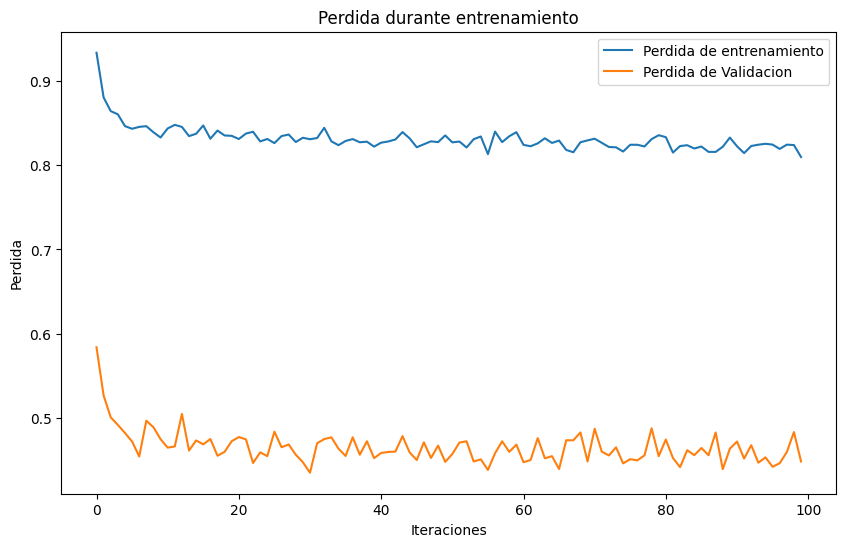

In [62]:
plt.figure(figsize=(10,6))
plt.plot(history1.history['loss'], label='Perdida de entrenamiento')
plt.plot(history1.history['val_loss'], label='Perdida de Validacion')
plt.plot()

plt.title("Perdida durante entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Perdida')
plt.legend()
plt.show()

In [63]:
y_pred = model1.predict(x_test)
y_pred = (tf.sigmoid(y_pred) > 0.5).numpy()

print(classification_report(y_test, y_pred))

# RESUMEN : DATASET DESBALANCEADO
# F1-SCORE : 0 - 0.95 -> 1 - 0.46

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      1400
           1       0.37      0.76      0.50       200

    accuracy                           0.81      1600
   macro avg       0.67      0.79      0.69      1600
weighted avg       0.89      0.81      0.84      1600



In [64]:
model2 = models.Sequential([
    layers.Dense(128, input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    layers.ReLU(),
    
	layers.Dense(64),
    layers.BatchNormalization(),
    layers.ReLU(),
    
	layers.Dense(32),
    layers.BatchNormalization(),
    layers.ReLU(),
    
	layers.Dense(16),
    layers.BatchNormalization(),
    layers.ReLU(),
    
	layers.Dense(1)
])

c:\Users\franc\Documents\pythonEnv\tfdev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [66]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
print(neg)
print(pos)

class_weight = {
    0: 1,
    1: neg/pos
}

print(class_weight)

4544
572
{0: 1, 1: np.float64(7.944055944055944)}


In [67]:
history2 = model2.fit(
    x_train,y_train,
    validation_data = (x_val, y_val),
    epochs = 100,
    batch_size = 32,
	class_weight=class_weight,
    verbose=1
)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8215 - loss: 0.9201 - val_accuracy: 0.9086 - val_loss: 0.4533
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.6717 - val_accuracy: 0.8930 - val_loss: 0.3800
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.5787 - val_accuracy: 0.8844 - val_loss: 0.3398
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8976 - loss: 0.4931 - val_accuracy: 0.8906 - val_loss: 0.3034
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9093 - loss: 0.4458 - val_accuracy: 0.9250 - val_loss: 0.2122
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9177 - loss: 0.4001 - val_accuracy: 0.9047 - val_loss: 0.2449
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9195 - loss: 0.3850 - val_accuracy: 0.9055 - val_loss: 0.2595
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9240 - loss: 0.3549 - val_accu

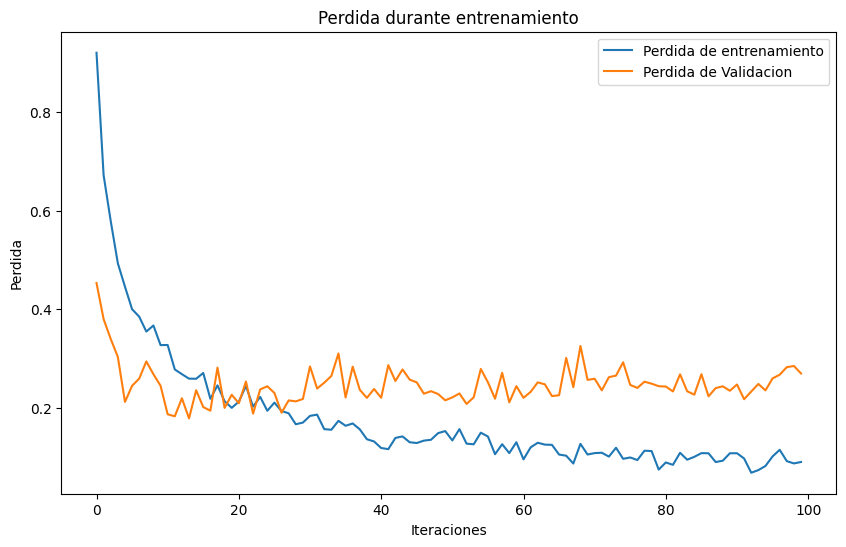

In [68]:
plt.figure(figsize=(10,6))
plt.plot(history2.history['loss'], label='Perdida de entrenamiento')
plt.plot(history2.history['val_loss'], label='Perdida de Validacion')
plt.plot()

plt.title("Perdida durante entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Perdida')
plt.legend()
plt.show()

In [69]:
y_pred = model2.predict(x_test)
y_pred = (tf.sigmoid(y_pred) > 0.5).numpy()

print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1400
           1       0.71      0.77      0.74       200

    accuracy                           0.93      1600
   macro avg       0.84      0.86      0.85      1600
weighted avg       0.93      0.93      0.93      1600



In [70]:
model3 = models.Sequential([
    layers.Dense(128, input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    
	layers.Dense(64),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    
	layers.Dense(32),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    
	layers.Dense(16),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    
	layers.Dense(1)
])

c:\Users\franc\Documents\pythonEnv\tfdev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [72]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
print(neg)
print(pos)

class_weight = {
    0: 1,
    1: neg/pos
}

print(class_weight)

4544
572
{0: 1, 1: np.float64(7.944055944055944)}


In [73]:
history3 = model3.fit(
    x_train,y_train,
    validation_data = (x_val, y_val),
    epochs = 100,
    batch_size = 32,
	class_weight=class_weight,
    verbose=1
)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7588 - loss: 1.2385 - val_accuracy: 0.8695 - val_loss: 0.5816
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 1.0541 - val_accuracy: 0.8562 - val_loss: 0.5312
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8149 - loss: 0.9503 - val_accuracy: 0.8602 - val_loss: 0.4790
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8217 - loss: 0.8856 - val_accuracy: 0.8695 - val_loss: 0.4289
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8292 - loss: 0.8427 - val_accuracy: 0.8711 - val_loss: 0.4065
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8411 - loss: 0.7949 - val_accuracy: 0.8742 - val_loss: 0.3628
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8401 - loss: 0.7615 - val_accuracy: 0.8641 - val_loss: 0.3776
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8384 - loss: 0.7436 - val_accu

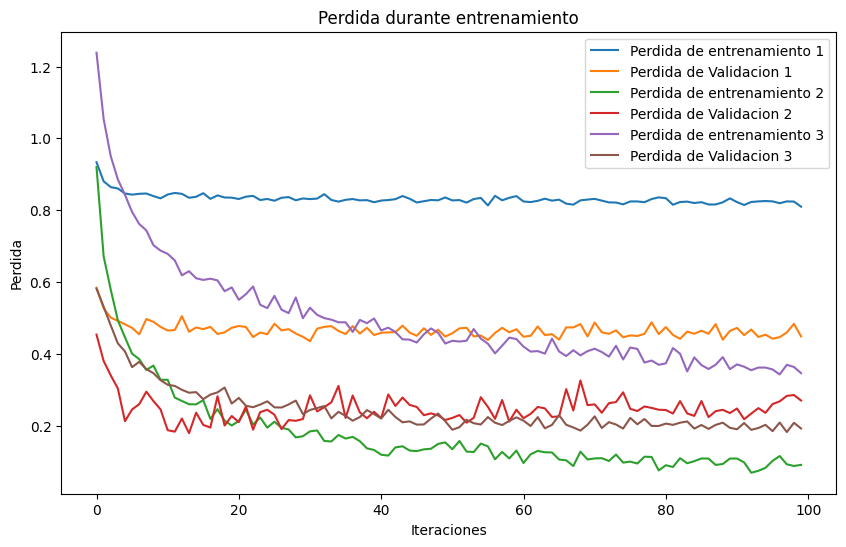

In [74]:
plt.figure(figsize=(10,6))
plt.plot(history1.history['loss'], label='Perdida de entrenamiento 1')
plt.plot(history1.history['val_loss'], label='Perdida de Validacion 1')
plt.plot(history2.history['loss'], label='Perdida de entrenamiento 2')
plt.plot(history2.history['val_loss'], label='Perdida de Validacion 2')
plt.plot(history3.history['loss'], label='Perdida de entrenamiento 3')
plt.plot(history3.history['val_loss'], label='Perdida de Validacion 3')
plt.plot()

plt.title("Perdida durante entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Perdida')
plt.legend()
plt.show()

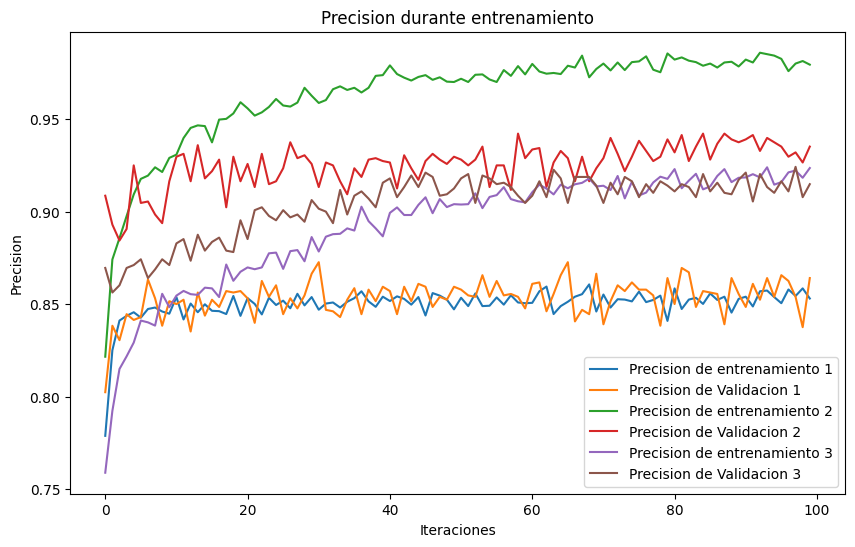

In [76]:
plt.figure(figsize=(10,6))
plt.plot(history1.history['accuracy'], label='Precision de entrenamiento 1')
plt.plot(history1.history['val_accuracy'], label='Precision de Validacion 1')
plt.plot(history2.history['accuracy'], label='Precision de entrenamiento 2')
plt.plot(history2.history['val_accuracy'], label='Precision de Validacion 2')
plt.plot(history3.history['accuracy'], label='Precision de entrenamiento 3')
plt.plot(history3.history['val_accuracy'], label='Precision de Validacion 3')
plt.plot()

plt.title("Precision durante entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [77]:
y_pred = model3.predict(x_test)
y_pred = (tf.sigmoid(y_pred) > 0.5).numpy()

print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1400
           1       0.58      0.94      0.72       200

    accuracy                           0.91      1600
   macro avg       0.79      0.92      0.83      1600
weighted avg       0.94      0.91      0.92      1600

